In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Data Cleaning**
### **Data Loading**

In [84]:
df = pd.read_csv('data.csv')

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (22676, 12)

Column names: ['Price', 'Apartment type', 'Metro station', 'Minutes to metro', 'Region', 'Number of rooms', 'Area', 'Living area', 'Kitchen area', 'Floor', 'Number of floors', 'Renovation']

Data types:
 Price               float64
Apartment type          str
Metro station           str
Minutes to metro    float64
Region                  str
Number of rooms     float64
Area                float64
Living area         float64
Kitchen area        float64
Floor               float64
Number of floors      int64
Renovation              str
dtype: object

First 5 rows:


,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
0,6300000.0,Secondary,Опалиха,6.0,Moscow region,1.0,30.6,11.1,8.5,25.0,25,Cosmetic
1,9000000.0,Secondary,Павшино,2.0,Moscow region,1.0,49.2,20.0,10.0,6.0,15,European-style renovation
2,11090000.0,Secondary,Мякинино,14.0,Moscow region,1.0,44.7,16.2,13.1,10.0,25,Cosmetic
3,8300000.0,Secondary,Строгино,8.0,Moscow region,1.0,35.1,16.0,11.0,12.0,33,European-style renovation
4,6450000.0,Secondary,Опалиха,6.0,Moscow region,1.0,37.7,15.2,4.0,5.0,5,Without renovation


### **Strip Whitespaces & Fix Data Types**

In [85]:
str_cols = df.select_dtypes(include=['object', 'str']).columns
df[str_cols] = df[str_cols].apply(lambda x: x.str.strip())
numeric_cols = ['Price', 'Minutes to metro', 'Number of rooms', 'Area', 'Living area', 'Kitchen area', 'Floor', 'Number of floors']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors = 'coerce')
print("Updated data types:\n", df.dtypes)
print("\nAny nulls introduced by coercion:\n", df[numeric_cols].isnull().sum())

Updated data types:
 Price               float64
Apartment type          str
Metro station           str
Minutes to metro    float64
Region                  str
Number of rooms     float64
Area                float64
Living area         float64
Kitchen area        float64
Floor               float64
Number of floors      int64
Renovation              str
dtype: object

Any nulls introduced by coercion:
 Price               0
Minutes to metro    0
Number of rooms     0
Area                0
Living area         0
Kitchen area        0
Floor               0
Number of floors    0
dtype: int64


### **Missing Values and Duplicates**

In [86]:
# Check for missing values
print("Missing values per Column:")
print(df.isnull().sum())
print(f'\nTotal Missing values: {df.isnull().sum().sum()}')

# Check for duplicate values
print(f'\nNumber of Duplicate Rows: {df.duplicated().sum()}')

# Remove Duplicates
df = df.drop_duplicates()
print(f"Shape after dropping duplicate rows: {df.shape}")

Missing values per Column:
Price               0
Apartment type      0
Metro station       0
Minutes to metro    0
Region              0
Number of rooms     0
Area                0
Living area         0
Kitchen area        0
Floor               0
Number of floors    0
Renovation          0
dtype: int64

Total Missing values: 0

Number of Duplicate Rows: 1851
Shape after dropping duplicate rows: (20825, 12)


### **Categorical Validation & Sanity Checks**

In [87]:
cat_cols = ['Apartment type', 'Region', 'Renovation']
for col in cat_cols:
    print(f"{col} ({df[col].nunique()} unique): {df[col].unique()}")
    print()

print(f"Metro station ({df['Metro station'].nunique()} unique): see value_counts() below")
print(df['Metro station'].value_counts())

Apartment type (2 unique): <ArrowStringArray>
['Secondary', 'New building']
Length: 2, dtype: str

Region (2 unique): <ArrowStringArray>
['Moscow region', 'Moscow']
Length: 2, dtype: str

Renovation (4 unique): <ArrowStringArray>
['Cosmetic', 'European-style renovation', 'Without renovation', 'Designer']
Length: 4, dtype: str

Metro station (317 unique): see value_counts() below
Metro station
Красногвардейская      2418
Депо                   1395
Братиславская          1001
Котельники              952
Жулебино                720
                       ... 
Партизанская              1
Долгопрудная              1
Лубянка                   1
Терехово (Мнёвники)       1
Сколково                  1
Name: count, Length: 317, dtype: int64


In [88]:
# Checks for some numeric features
invalid_floor = df[df['Floor'] > df['Number of floors']]
invalid_living = df[df['Living area'] > df['Area']]
invalid_kitchen = df[df['Kitchen area'] > df['Area']]
invalid_area = df[df['Living area'] + df['Kitchen area'] > df['Area']]

print(f"Rows where Floor > Number of floors: {len(invalid_floor)}")
print(f"Rows where Living area > Total area: {len(invalid_living)}")
print(f"Rows where Kitchen area > Total area: {len(invalid_kitchen)}")
print(f"Rows where Kitchen + Living area > Total area: {len(invalid_area)}")

Rows where Floor > Number of floors: 1502
Rows where Living area > Total area: 0
Rows where Kitchen area > Total area: 1
Rows where Kitchen + Living area > Total area: 956


### **Drop Invalid Rows**

In [89]:
before = len(df)

df = df[df['Floor'] <= df['Number of floors']]
df = df[df['Kitchen area'] <= df['Area']]
df = df[df['Kitchen area'] + df['Living area'] <= df['Area']]

df = df.reset_index(drop=True)
print("Index reset complete.")

after = len(df)
print(f"Rows removed: {before - after}")
print(f"Final shape: {df.shape}")

Index reset complete.
Rows removed: 2451
Final shape: (18374, 12)


### **Cleaned Data Summary**

In [90]:
print(f"Final dataset shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nDescriptive statistics:")
df.describe()

Final dataset shape: (18374, 12)

Data types:
Price               float64
Apartment type          str
Metro station           str
Minutes to metro    float64
Region                  str
Number of rooms     float64
Area                float64
Living area         float64
Kitchen area        float64
Floor               float64
Number of floors      int64
Renovation              str
dtype: object

Descriptive statistics:


,Price,Minutes to metro,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors
count,1.837400e+04,18374.000000,18374.000000,18374.000000,18374.000000,18374.000000,18374.000000,18374.000000
mean,3.693260e+07,11.813214,2.168826,73.415699,39.405807,12.608049,8.790682,17.220366
std,8.338087e+07,6.349021,1.471186,66.200141,36.982941,7.776035,7.239024,9.870138
min,2.261523e+06,0.000000,0.000000,9.000000,2.000000,1.000000,1.000000,1.000000
25%,7.600000e+06,7.000000,1.000000,39.000000,19.000000,8.700000,4.000000,11.000000
50%,1.244792e+07,11.000000,2.000000,54.700000,29.300000,10.800000,7.000000,16.000000
75%,2.655719e+07,15.000000,3.000000,79.600000,44.300000,14.700000,12.000000,20.000000
max,2.455020e+09,60.000000,12.000000,1117.000000,566.800000,122.000000,92.000000,97.000000


In [91]:
# Upload cleaned csv file
df.to_csv('data_cleaned.csv', index=False)
print("Cleaned data saved to data_cleaned.csv")

Cleaned data saved to data_cleaned.csv


# **EDA**
### **Target Variable (Price) Analysis**

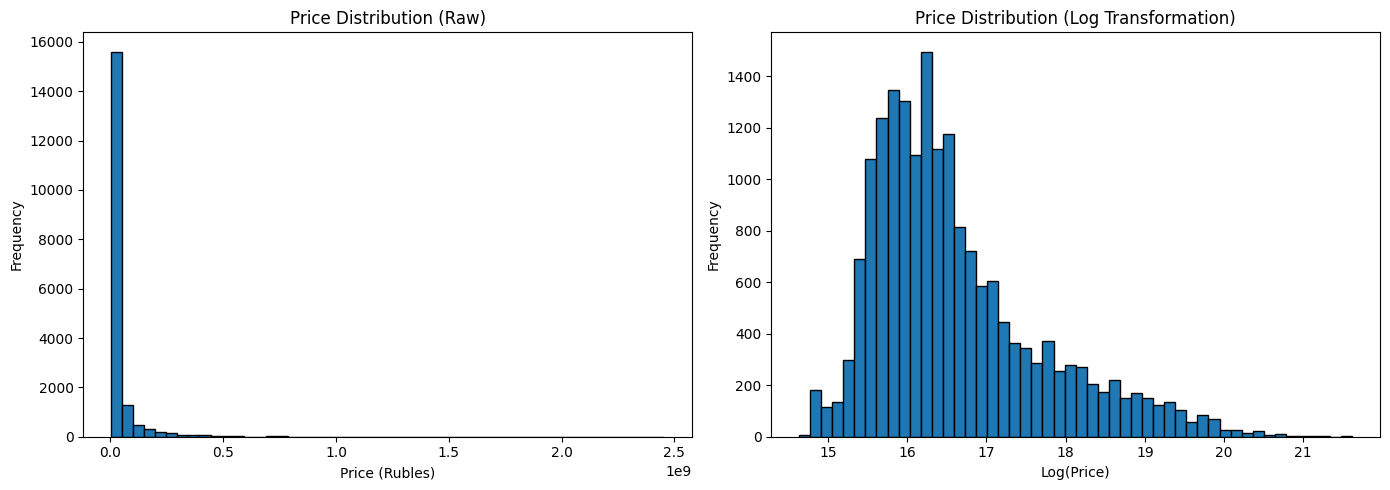

Price skewness (raw): 7.6307
Price skewness (log): 1.1332


In [92]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))
ax1, ax2 = axes
# Raw Price Distribution
ax1.hist(df['Price'], bins = 50, edgecolor='black')
ax1.set_title('Price Distribution (Raw)')
ax1.set_xlabel('Price (Rubles)')
ax1.set_ylabel('Frequency')

ax2.hist(np.log(df['Price']), bins=50, edgecolor='black')
ax2.set_title('Price Distribution (Log Transformation)')
ax2.set_xlabel('Log(Price)')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Price skewness (raw): {df['Price'].skew():.4f}")
print(f"Price skewness (log): {np.log(df['Price']).skew():.4f}")

In [93]:
df['Log_Price'] = np.log(df['Price'])

### **Numeric Feature Distribution**

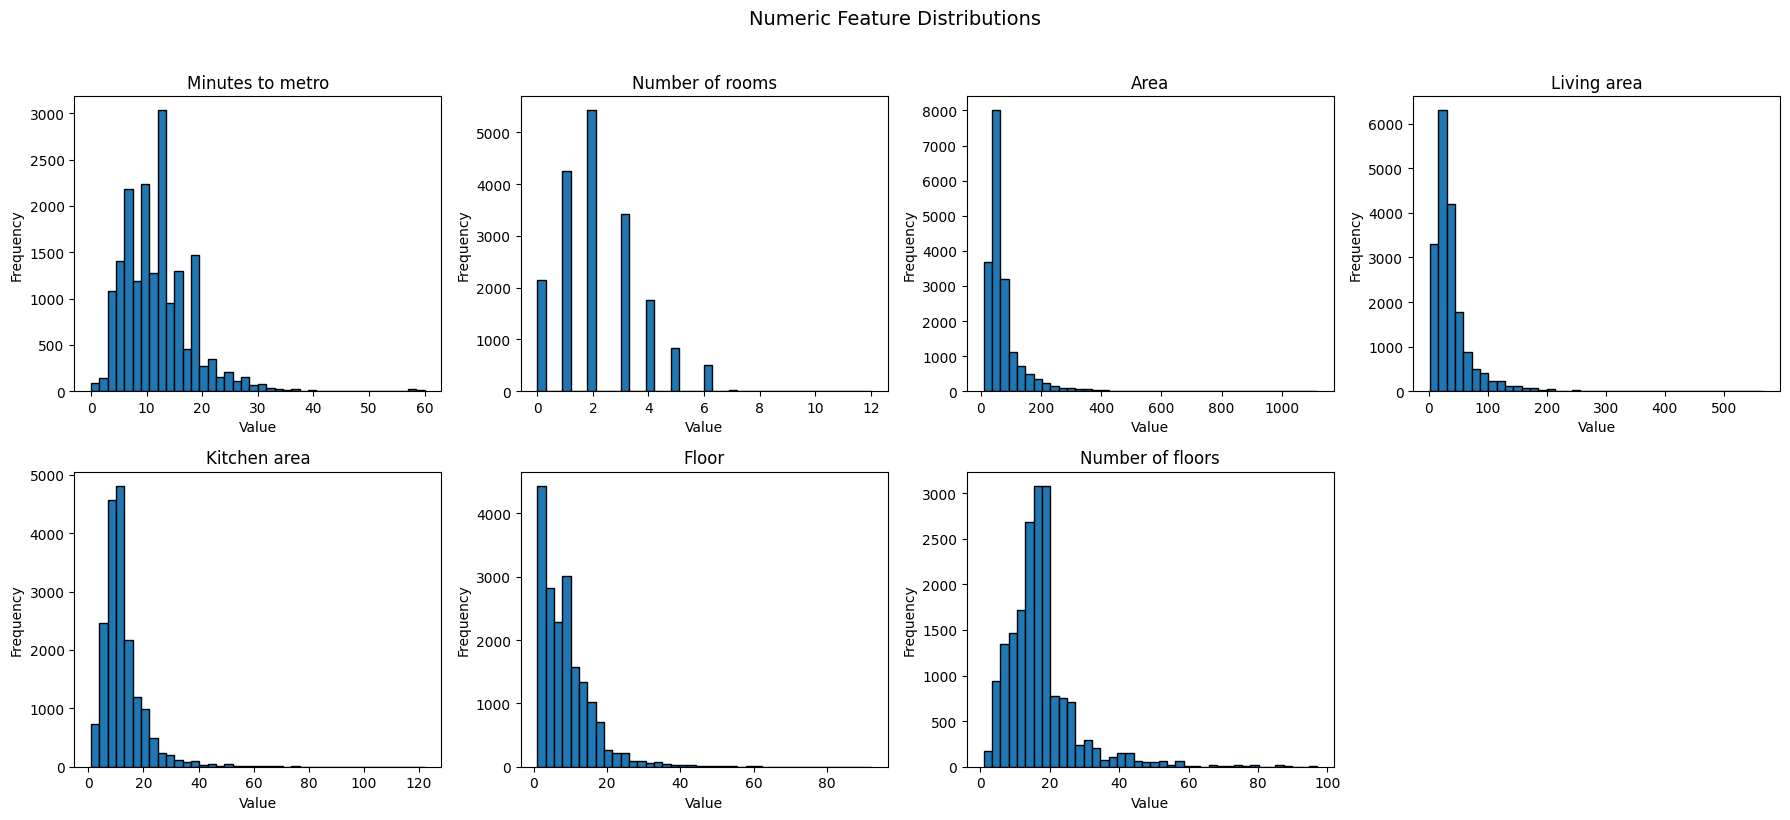

In [94]:
numeric_cols =  ['Minutes to metro', 'Number of rooms', 'Area', 
                'Living area', 'Kitchen area', 'Floor', 'Number of floors']
fig, axes = plt.subplots(2, 4, figsize=(18,8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col], bins = 40, edgecolor = 'black')
    ax.set_title(f'{col}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

axes[-1].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### **Correlation Heatmap**

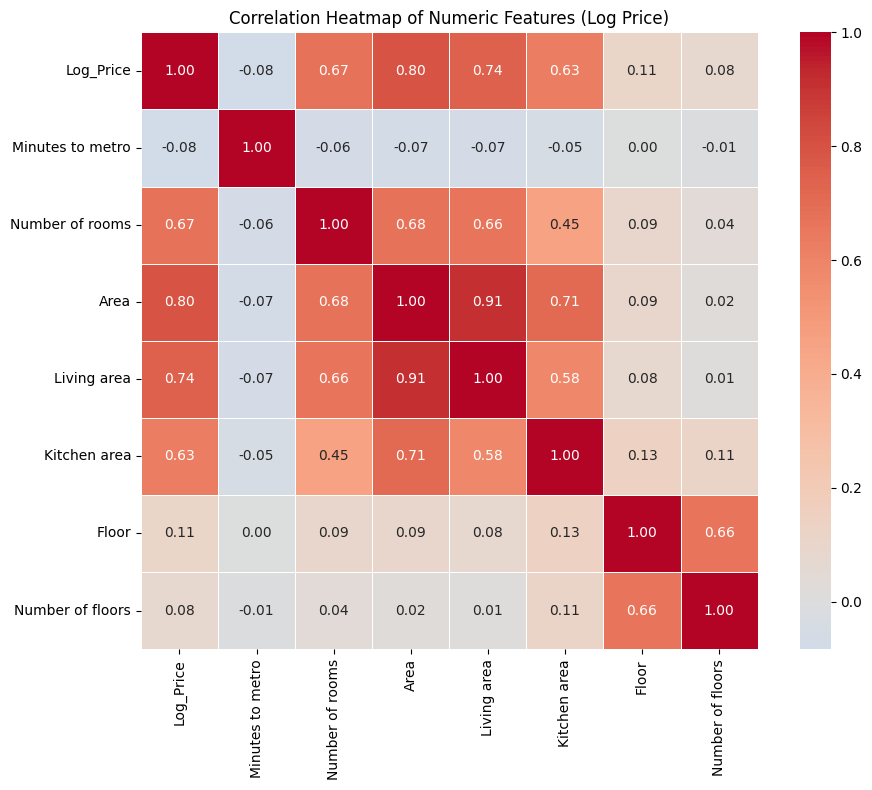

In [99]:
corr_features = ['Log_Price'] + numeric_cols

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features (Log Price)')
plt.tight_layout()
plt.show()

Correlations with log(Price) — strongest to weakest:

* Area: 0.80 — strongest numeric predictor
* Living area: 0.74 — strong, but nearly redundant with Area (corr = 0.91)
* Number of rooms: 0.67 — strong ordinal predictor
* Kitchen area: 0.63 — moderate
* Floor: 0.11 — weak but no longer negligible
* Number of floors: 0.08 — weak
* Minutes to metro: -0.08 — remains the weakest predictor


### **Categorical Feature Analysis**

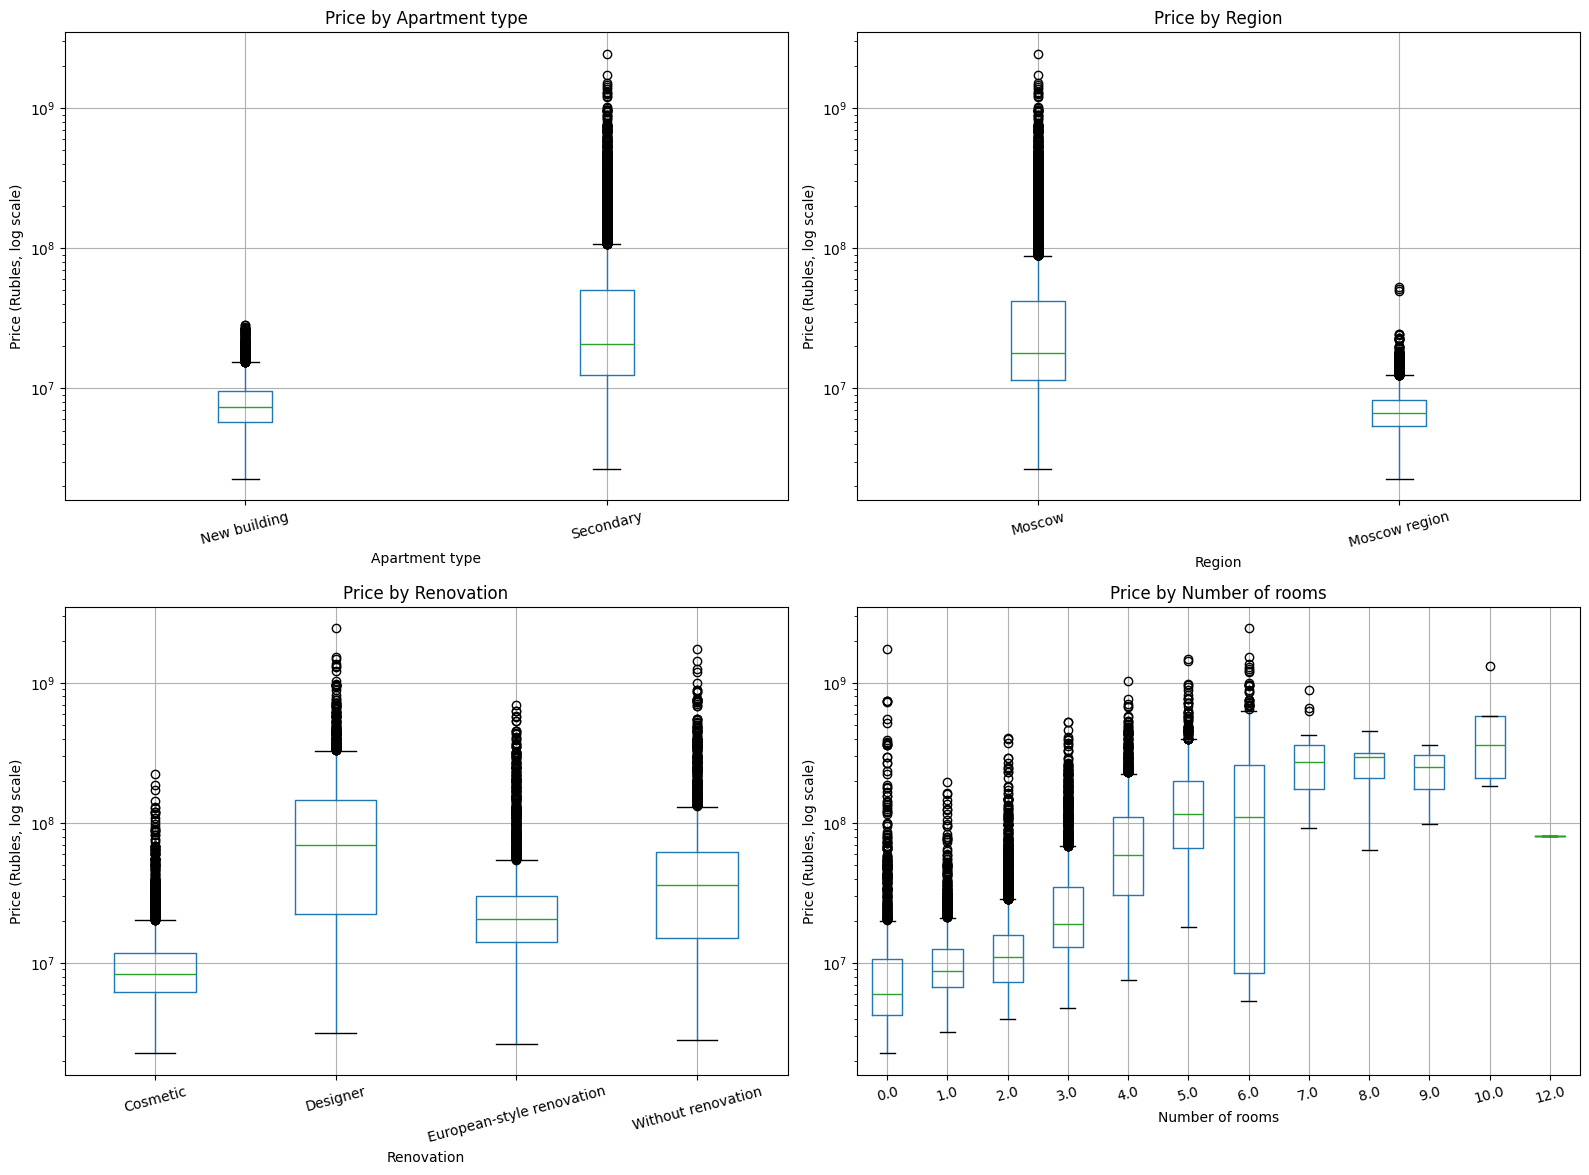

In [100]:
cat_cols = ['Apartment type', 'Region', 'Renovation', 'Number of rooms']

fig, axes = plt.subplots(2, 2, figsize = (16, 12))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    df.boxplot(column='Price', by=col, ax=ax)
    ax.set_title(f'Price by {col}')
    ax.set_xlabel(col)
    ax.set_yscale('log')
    ax.set_ylabel('Price (Rubles, log scale)')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('')
plt.tight_layout()
plt.show()

### **Feature vs. Price Scatter Plots**

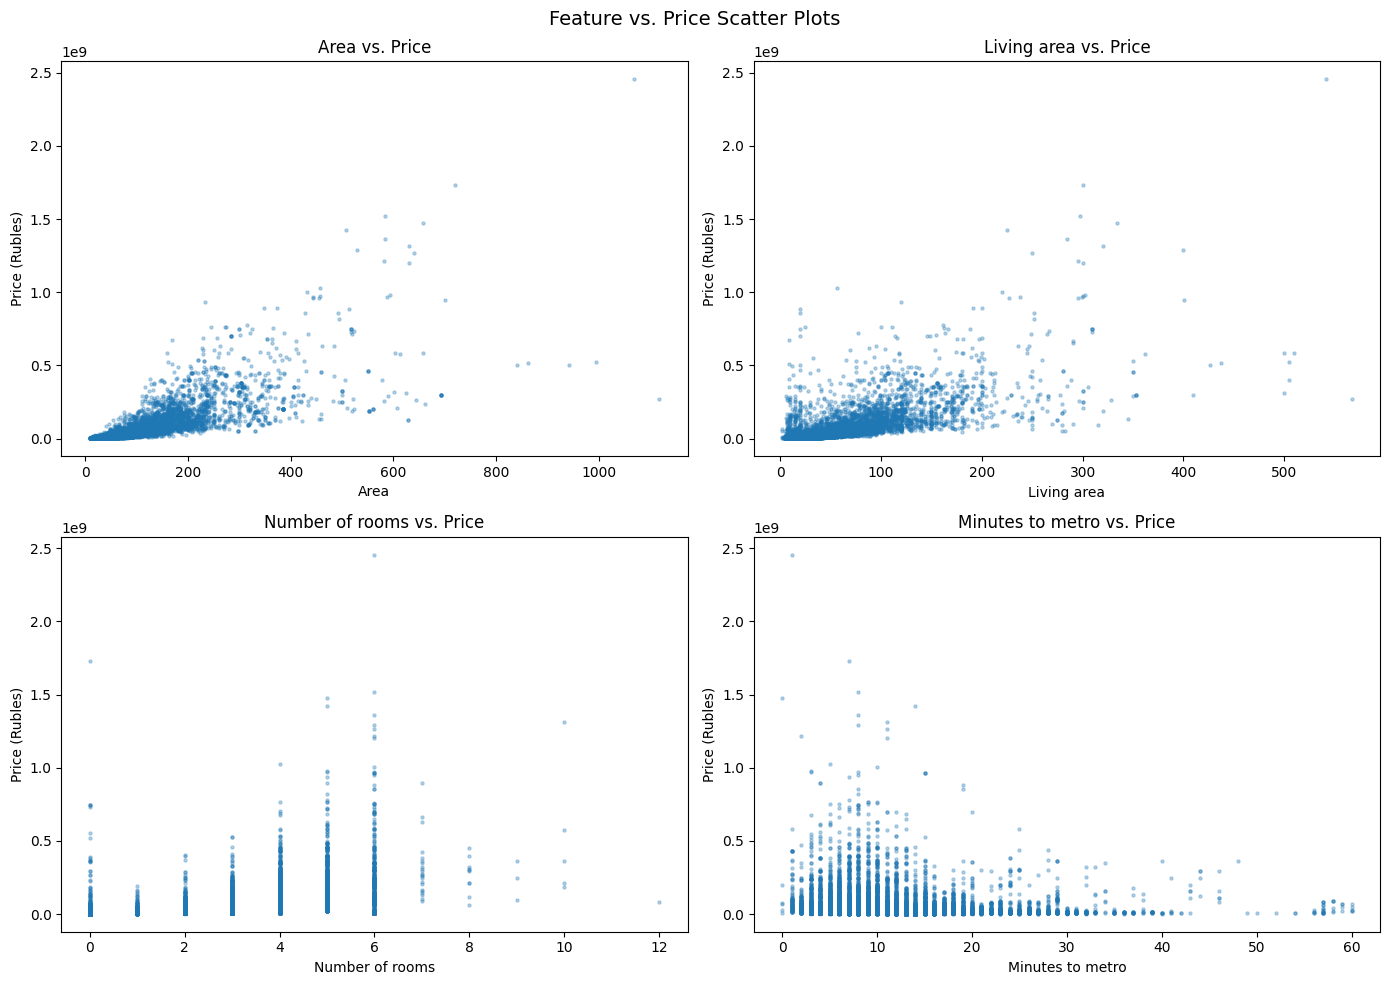

In [97]:
scatter_cols = ['Area', 'Living area', 'Number of rooms', 'Minutes to metro']
fig, axes = plt.subplots(2, 2, figsize = (14, 10))
axes = axes.flatten()

for ax, col in zip(axes, scatter_cols):
    ax.scatter(df[col], df['Price'], alpha=0.3, s=5)
    ax.set_xlabel(col)
    ax.set_ylabel('Price (Rubles)')
    ax.set_title(f'{col} vs. Price')

plt.suptitle('Feature vs. Price Scatter Plots', fontsize = 14)
plt.tight_layout()
plt.show()

### **EDA Summary**

Key findings from exploratory data analysis:

- **Price** is heavily right-skewed (raw skewness ≈ 7.63); log-transformation 
  significantly reduces skewness (log skewness ≈ 1.13), though the distribution 
  remains moderately right-skewed

- When correlations are computed against **log(Price)** (the more appropriate scale 
  given the skew), the feature importance picture shifts materially:
  - **Area** (0.80) remains the strongest numeric predictor
  - **Living area** (0.74) — strong, but nearly redundant with Area
  - **Number of rooms** (0.67) — rises substantially from 0.47 on raw Price
  - **Kitchen area** (0.63) — also stronger than raw Price suggested (0.56)
  - **Floor** (0.11) and **Number of floors** (0.08) — no longer effectively zero
  - **Minutes to metro** (-0.08) — remains the weakest predictor

- **Area** and **Living area** are highly correlated with each other (0.91) — 
  multicollinearity to watch in linear models; Lasso will likely drop one

- **Renovation type** and **Region** show meaningful price differences — 
  Designer renovation and Moscow location command clear premiums

- Price variance grows with apartment size (heteroscedasticity) — visible in 
  scatter plots

- **Number of rooms** might behave more like an ordinal categorical variable, so changing it could be something to consider.

